![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)  
This work by Jephian Lin is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Main idea

If $\|{\bf u}\| = 1$, then the projection of ${\bf v}$ onto ${\bf u}$ is
$$\operatorname{proj}_{\bf u}({\bf v}) = \langle{\bf v}, {\bf u}\rangle{\bf u}.$$

If $S = \{{\bf u}_1,\ldots, {\bf u}_d\}$ is a collection of mutually orthogonal vectors of length one, then the projection of ${\bf v}$ onto $V = \operatorname{span}(S)$ is
$$\operatorname{proj}_V({\bf v}) = \langle{\bf v}, {\bf u}_1\rangle{\bf u}_1 + \cdots + \langle{\bf v}, {\bf u}_d\rangle{\bf u}_d.$$
We say such $S$ is an **orthonormal basis** of $V$.

Suppose $S = \{{\bf u}_1,\ldots, {\bf u}_d\}$ is an orthonormal basis of $V = \operatorname{span}(S)$.  
Let

$$
    A = \begin{bmatrix}
     | & ~ & | \\
     {\bf u}_1 & \cdots & {\bf u}_d \\
     | & ~ & | \\
    \end{bmatrix}.
$$  

Then $A^\top A = I$ and the projection is  
$$\operatorname{proj}_V({\bf v}) = AA^\top{\bf v}.$$

Suppose  
$${\bf v} = c_1{\bf u}_1 + \cdots + c_d{\bf u}_d$$
is a vector in $\operatorname{span}(S)$.  
Then $A^\top {\bf v} = {\bf c}$ and $A{\bf c} = {\bf v}$,  
where  
$${\bf c} = \begin{bmatrix} c_1 \\ \vdots \\ c_d \end{bmatrix} \text{ and }  
A = \begin{bmatrix}
 | & ~ & | \\
 {\bf u}_1 & \cdots & {\bf u}_d \\
 | & ~ & | \\
\end{bmatrix}.$$  


Every space has an orthonormal basis.

## Side stories

- projection
- Gram--Schmidt process

## Experiments

###### Exercise 1
Let  
```python
u = np.array([1,1])
u = u / np.linalg.norm(u)
v = np.array([3,4])
```

###### 1(a)
Print $\langle {\bf v}, {\bf u}\rangle$.

In [3]:
### your answer here
u = np.array([1,1])
u = u / np.linalg.norm(u)
v = np.array([3,4])
print(np.dot(v,u))

4.949747468305832


###### 1(b)
Draw a vector in black for ${\bf u}$.  
Draw a vector in blue for ${\bf v}$.  
Draw a vector in red with dashed line for the projection of ${\bf v}$ onto ${\bf u}$.  

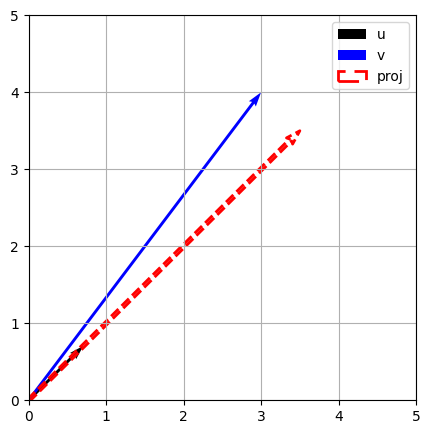

In [7]:
### your answer here
u = np.array([1,1])
u = u / np.linalg.norm(u)
v = np.array([3,4])
proj = np.dot(v, u) * u

plt.figure(figsize=(5,5))
args = {'angles': 'xy', 'scale_units': 'xy', 'scale': 1}

plt.quiver(0, 0, u[0], u[1], color='black', label='u', **args)
plt.quiver(0, 0, v[0], v[1], color='blue', label='v', **args)
plt.quiver(0, 0, proj[0], proj[1], color='red', linestyle='--',
           linewidth=2, facecolor='none', edgecolor='red', label='proj', **args)

plt.axis([0, 5, 0, 5])
plt.legend()
plt.grid()
plt.show()


###### Exercise 2
Let  
```python
u0 = np.array([1,-1,0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1,1,-2])
u1 = u1 / np.linalg.norm(u1)
v = np.array([1,0,0])
```
Let $V$ be the space spanned by $\{{\bf u}_0,{\bf u}_1\}$.

###### 2(a)
Use the technique you learned in the previous lesson to find the projection of ${\bf v}$ onto $V$.

In [8]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
v = np.array([1, 0, 0])

proj_v = np.dot(v, u0) * u0 + np.dot(v, u1) * u1

print(f"Projection of v onto V: {proj_v}")

Projection of v onto V: [ 0.66666667 -0.33333333 -0.33333333]


###### 2(b)
Compute $c_0 = \langle {\bf v},{\bf u}_0\rangle$ and $c_1 = \langle {\bf v},{\bf u}_1\rangle$.  
Check if $c_0{\bf u}_0 + c_1{\bf u}_1$ is the same as your answer in 2(a).

In [10]:
### your answer here
u0 = np.array([1,-1,0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1,1,-2])
u1 = u1 / np.linalg.norm(u1)
v = np.array([1,0,0])

c0 = np.dot(v, u0)
c1 = np.dot(v, u1)

proj_v = c0 * u0 + c1 * u1

print(f"c0: {c0:.4f}, c1: {c1:.4f}")
print(f"投影結果: {proj_v}")
print(f"驗證 (2/3, -1/3, -1/3): {np.allclose(proj_v, [2/3, -1/3, -1/3])}")

c0: 0.7071, c1: 0.4082
投影結果: [ 0.66666667 -0.33333333 -0.33333333]
驗證 (2/3, -1/3, -1/3): True


###### 2(c)
Compute $A^\top{\bf v}$ and check if the output is the same as $c_0$ and $c_1$ you computed in 2(b).

In [11]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
v = np.array([1, 0, 0])

A = np.column_stack([u0, u1])

Atv = A.T @ v

c_previous = np.array([np.dot(v, u0), np.dot(v, u1)])

print(f"A^T @ v 的結果: {Atv}")
print(f"2(b) 的 [c0, c1]: {c_previous}")
print(f"兩者是否一致: {np.allclose(Atv, c_previous)}")

A^T @ v 的結果: [0.70710678 0.40824829]
2(b) 的 [c0, c1]: [0.70710678 0.40824829]
兩者是否一致: True


###### 2(d)
Check if $AA^\top{\bf v}$ is again the same as the answer you computed in 2(b).

In [12]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
v = np.array([1, 0, 0])

A = np.column_stack([u0, u1])

AATv = A @ A.T @ v

proj_2b = np.dot(v, u0) * u0 + np.dot(v, u1) * u1

print(f"AA^T v:\n{AATv}")
print(f"2(b) Result:\n{proj_2b}")
print(f"一致性檢查: {np.allclose(AATv, proj_2b)}")

AA^T v:
[ 0.66666667 -0.33333333 -0.33333333]
2(b) Result:
[ 0.66666667 -0.33333333 -0.33333333]
一致性檢查: True


## Exercises

###### Exercise 3
Let  
```python
u0 = np.array([1,-1,0])
u1 = np.array([1,1,-2])
u2 = np.array([1,1,1])
u0 = u0 / np.linalg.norm(u0)
u1 = u1 / np.linalg.norm(u1)
u2 = u2 / np.linalg.norm(u2)
```
and $S = \{{\bf u}_0, {\bf u}_1, {\bf u}_2\}$.  

###### 3(a)
Check if the vectors in $S$ are mutually orthogonal and al have length one.  
Can you check it by $A^\top A$ for some appropriate $A$?

In [14]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
u2 = np.array([1, 1, 1])
u2 = u2 / np.linalg.norm(u2)

A = np.column_stack([u0, u1, u2])

result = A.T @ A

print("A^T @ A 的結果：")
print(np.round(result, 10))

is_orthonormal = np.allclose(result, np.eye(3))
print(f"\n這組向量是否為相互正交且長度為一？ {is_orthonormal}")

A^T @ A 的結果：
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

這組向量是否為相互正交且長度為一？ True


###### 3(b)
Let  
```python
v = np.array([1,0,0])
```
Find $c_0,c_1,c_2$ such that ${\bf v} = c_0{\bf u}_0 + c_1{\bf u}_1 + c_2{\bf u}_2$.

In [15]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
u2 = np.array([1, 1, 1])
u2 = u2 / np.linalg.norm(u2)
v = np.array([1, 0, 0])

A = np.column_stack([u0, u1, u2])

c = A.T @ v

v_reconstructed = c[0]*u0 + c[1]*u1 + c[2]*u2

print(f"c0 = {c[0]:.4f}")
print(f"c1 = {c[1]:.4f}")
print(f"c2 = {c[2]:.4f}")
print(f"\n驗證重建的 v: {v_reconstructed}")
print(f"是否與原 v 相等: {np.allclose(v, v_reconstructed)}")

c0 = 0.7071
c1 = 0.4082
c2 = 0.5774

驗證重建的 v: [1.00000000e+00 2.77555756e-16 0.00000000e+00]
是否與原 v 相等: True


###### 3(c)
Draw the vectors ${\bf v}$, ${\bf u}_0$, ${\bf u}_1$, and ${\bf u}_2$.

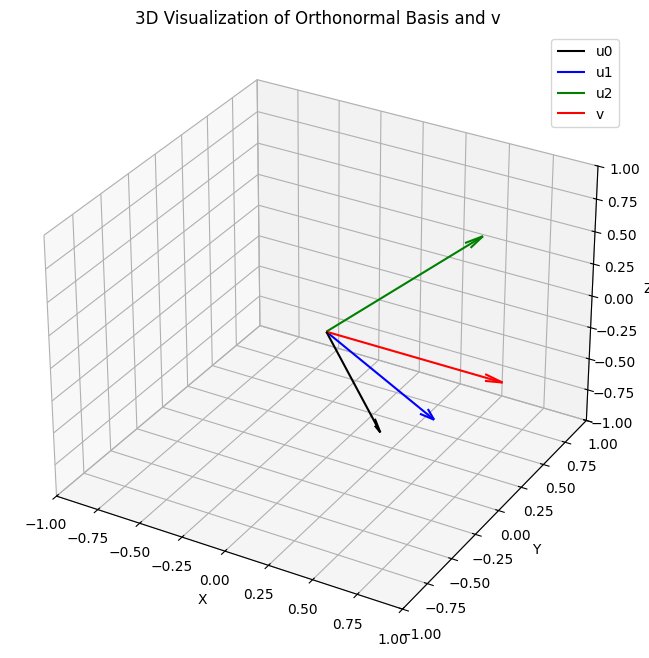

In [16]:
### your answer here
u0 = np.array([1, -1, 0])
u0 = u0 / np.linalg.norm(u0)
u1 = np.array([1, 1, -2])
u1 = u1 / np.linalg.norm(u1)
u2 = np.array([1, 1, 1])
u2 = u2 / np.linalg.norm(u2)
v = np.array([1, 0, 0])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def draw_vec(vec, color, label):
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2],
              color=color, label=label, arrow_length_ratio=0.1)

draw_vec(u0, 'black', 'u0')
draw_vec(u1, 'blue',  'u1')
draw_vec(u2, 'green', 'u2')
draw_vec(v,  'red',   'v')

ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('3D Visualization of Orthonormal Basis and v')
ax.legend()
plt.show()

##### Exercise 4
Let  
```python
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0],
              [0,0,-1]])
```
and ${\bf u}_0, {\bf u}_1, {\bf u}_2$ the columns of $A$.  
The following exercises lead you through the process of finding an orthnormal basis of $\operatorname{Col}(A)$.

In [ ]:
### your answer here
A = np.array([[1, 1, 1],
              [-1, 0, 0],
              [0, -1, 0],
              [0, 0, -1]])

u0 = A[:, 0]
u_hat_0 = u0 / np.linalg.norm(u0)

print(f"u0: {u0}")

###### 4(a)
Compute $\hat{\bf u}_0 = {\bf u}_0 / \|{\bf u}_0\|$.

In [26]:
### your answer here
A = np.array([[1, 1, 1],
              [-1, 0, 0],
              [0, -1, 0],
              [0, 0, -1]])

u0 = A[:, 0]
u_hat_0 = u0 / np.linalg.norm(u0)

print(f"u0: {u0}")

u0: [ 1 -1  0  0]


###### 4(b)
Let $V_0$ be the space spanned by $\{\hat{\bf u}_0\}$.  
Compute ${\bf u}'_1 = {\bf u}_1 - \operatorname{proj}_{V_0}({\bf u}_1)$ and $\hat{\bf u}_1 = {\bf u}'_1 / \|{\bf u}'_1\|$.

In [28]:
### your answer here
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0],
              [0,0,-1]])
u0 = A[:, 0]
u1 = A[:, 1]

u_hat_0 = u0 / np.linalg.norm(u0)
proj_V0_u1 = np.dot(u1, u_hat_0) * u_hat_0
u_prime_1 = u1 - proj_V0_u1
u_hat_1 = u_prime_1 / np.linalg.norm(u_prime_1)

print(f"u0: {u0}")
print(f"u_prime_1: {u_prime_1}")
print(f"u_hat_1: {u_hat_1}")

u0: [ 1 -1  0  0]
u_prime_1: [ 0.5  0.5 -1.   0. ]
u_hat_1: [ 0.40824829  0.40824829 -0.81649658  0.        ]


###### 4(c)
Let $V_1$ be the space spanned by $\{\hat{\bf u}_0,\hat{\bf u}_1\}$.  
Compute ${\bf u}'_2 = {\bf u}_2 - \operatorname{proj}_{V_1}({\bf u}_2)$ and $\hat{\bf u}_2 = {\bf u}'_2 / \|{\bf u}'_2\|$.

In [29]:
### your answer here
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0],
              [0,0,-1]])
u0 = A[:, 0]
u1 = A[:, 1]
u2 = A[:, 2]

u_hat_0 = u0 / np.linalg.norm(u0)
u_prime_1 = u1 - np.dot(u1, u_hat_0) * u_hat_0
u_hat_1 = u_prime_1 / np.linalg.norm(u_prime_1)

proj_V1_u2 = np.dot(u2, u_hat_0) * u_hat_0 + np.dot(u2, u_hat_1) * u_hat_1
u_prime_2 = u2 - proj_V1_u2
u_hat_2 = u_prime_2 / np.linalg.norm(u_prime_2)

print(f"u0: {u0}")
print(f"u_prime_1: {u_prime_1}")
print(f"u_hat_1: {u_hat_1}")
print(f"u_prime_2: {u_prime_2}")
print(f"u_hat_2: {u_hat_2}")

u0: [ 1 -1  0  0]
u_prime_1: [ 0.5  0.5 -1.   0. ]
u_hat_1: [ 0.40824829  0.40824829 -0.81649658  0.        ]
u_prime_2: [ 0.33333333  0.33333333  0.33333333 -1.        ]
u_hat_2: [ 0.28867513  0.28867513  0.28867513 -0.8660254 ]


###### 4(d)
Check if $\hat{S} = \{\hat{\bf u}_0, \hat{\bf u}_1, \hat{\bf u}_2\}$ is an orthogonal basis of $\operatorname{Col}(A)$.

In [40]:
### your answer here
np.set_printoptions(precision=4, suppress=True)
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0],
              [0,0,-1]])
u0 = A[:, 0]
u1 = A[:, 1]
u2 = A[:, 2]

u_hat_0 = u0 / np.linalg.norm(u0)
u_prime_1 = u1 - np.dot(u1, u_hat_0) * u_hat_0
u_hat_1 = u_prime_1 / np.linalg.norm(u_prime_1)

proj_V1_u2 = np.dot(u2, u_hat_0) * u_hat_0 + np.dot(u2, u_hat_1) * u_hat_1
u_prime_2 = u2 - proj_V1_u2
u_hat_2 = u_prime_2 / np.linalg.norm(u_prime_2)

print("u0: ", u0)
print("u_prime_1: ", u_prime_1)
print("u_hat_1: ", u_hat_1)
print("u_prime_2: ", u_prime_2)
print("u_hat_2: ", u_hat_2)

Q = np.column_stack([u_hat_0, u_hat_1, u_hat_2])
check_ortho = Q.T @ Q

print("Q.T @ Q:")
print(np.round(check_ortho, 10))

combined = np.hstack([A, Q])
rank_A = np.linalg.matrix_rank(A)
rank_combined = np.linalg.matrix_rank(combined)

print("\nmagnitude is 1: ", np.allclose(np.diag(check_ortho), 1))
print("orthogonal: ", np.allclose(check_ortho - np.eye(3), 0))
print("span: ", rank_A == rank_combined)

u0:  [ 1 -1  0  0]
u_prime_1:  [ 0.5  0.5 -1.   0. ]
u_hat_1:  [ 0.4082  0.4082 -0.8165  0.    ]
u_prime_2:  [ 0.3333  0.3333  0.3333 -1.    ]
u_hat_2:  [ 0.2887  0.2887  0.2887 -0.866 ]
Q.T @ Q:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

magnitude is 1:  True
orthogonal:  True
span:  True


In [44]:
import numpy as np

def normalize(v):
    """將向量長度調為 1 的函式"""
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v

# 1. 定義矩陣 A 與原始行向量
A = np.array([
    [ 1,  1,  1],
    [-1,  0,  0],
    [ 0, -1,  0],
    [ 0,  0, -1]
], dtype=float)

u0, u1, u2 = A[:, 0], A[:, 1], A[:, 2]

# 2. Gram-Schmidt 過程 (含中間變數)

# --- 第一組向量 ---
u_hat_0 = normalize(u0)

# --- 第二組向量 ---
u_prime_1 = u1 - np.dot(u1, u_hat_0) * u_hat_0
u_hat_1 = normalize(u_prime_1)

# --- 第三組向量 ---
# 扣除在 u_hat_0 與 u_hat_1 兩個方向上的投影
u_prime_2 = u2 - (np.dot(u2, u_hat_0) * u_hat_0 + np.dot(u2, u_hat_1) * u_hat_1)
u_hat_2 = normalize(u_prime_2)

# 3. 輸出中間運算結果
print("=== 中間向量結果 ===")
print(f"u0:        {u0}")
print(f"u_prime_1: {u_prime_1}")
print(f"u_hat_1:   {u_hat_1}")
print(f"u_prime_2: {u_prime_2}")
print(f"u_hat_2:   {u_hat_2}\n")

# 4. 組成正交矩陣 Q 並驗證
Q = np.column_stack([u_hat_0, u_hat_1, u_hat_2])
check_ortho = Q.T @ Q

print("=== 矩陣驗證 ===")
print("Q.T @ Q (正交規範性檢查):")
print(check_ortho)

# 5. 自動化檢查
rank_A = np.linalg.matrix_rank(A)
rank_combined = np.linalg.matrix_rank(np.hstack([A, Q]))

lengths = np.linalg.norm(Q, axis=0)

print(f"\n✅ 長度檢查：{'通過' if np.allclose(lengths, 1) else '失敗'} (各向量長度: {lengths})")
print(f"✅ 正交檢查：{'通過' if np.allclose(check_ortho, np.eye(3)) else '失敗'}")
print(f"✅ 空間一致：{'是' if rank_A == rank_combined else '否'}")

=== 中間向量結果 ===
u0:        [ 1. -1.  0.  0.]
u_prime_1: [ 0.5  0.5 -1.   0. ]
u_hat_1:   [ 0.4082  0.4082 -0.8165  0.    ]
u_prime_2: [ 0.3333  0.3333  0.3333 -1.    ]
u_hat_2:   [ 0.2887  0.2887  0.2887 -0.866 ]

=== 矩陣驗證 ===
Q.T @ Q (正交規範性檢查):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

✅ 長度檢查：通過 (各向量長度: [1. 1. 1.])
✅ 正交檢查：通過
✅ 空間一致：是


#### Remark
This process is called the **Gram--Schmidt process**.  
It takes a basis $S = \{{\bf u}_0, \ldots, {\bf u}_{d-1}\}$ and returns an orthogonal basis $\hat{S} = \{\hat{\bf u}_0, \ldots, \hat{\bf u}_{d-1}\}$ such that $\operatorname{span}(S) = \operatorname{span}(\hat{S})$ by the following steps.
1. $\hat{\bf u}_0 = {\bf u}_0$
2. Let $V_{k-1}$ be the space spanned by $\{\hat{\bf u}_0,\ldots, \hat{\bf u}_{k-1}\}$.  Then $\hat{\bf u}_{k} = {\bf u}_{k} - \operatorname{proj}_{V_k}({\bf u}_{k})$.  Repeat this step for $k = 1,\ldots, d-1$.
3. Normalize each vector of $\{\hat{\bf u}_0, \ldots, \hat{\bf u}_{d-1}\}$ to length one.

##### Exercise 5
Write a function that takes a basis (stored as the columns of $A$) and returns an orthogonal basis (stored as the columns of $B$).

In [24]:
### your answer here
def gram_schmidt(A):
    A = A.astype(float)
    n_cols = A.shape[1]
    B = np.zeros_like(A)

    for i in range(n_cols):
        v = A[:, i]

        projection = np.zeros_like(v)
        for j in range(i):
            projection += np.dot(v, B[:, j]) * B[:, j]

        u_prime = v - projection
        B[:, i] = u_prime / np.linalg.norm(u_prime)

    return B

# --- 測試與驗證 ---
A_test = np.array([[1, 1, 1], [-1, 0, 0], [0, -1, 0], [0, 0, -1]])
B = gram_schmidt(A_test)

print("正交規範基 B:")
print(B)
print("\n驗證 B^T @ B (應為單位矩陣):")
print(np.round(B.T @ B, 10))

正交規範基 B:
[[ 0.70710678  0.40824829  0.28867513]
 [-0.70710678  0.40824829  0.28867513]
 [ 0.         -0.81649658  0.28867513]
 [ 0.          0.         -0.8660254 ]]

驗證 B^T @ B (應為單位矩陣):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
